In [1]:
%load_ext autoreload
%autoreload 2
from utils import *
import numpy as np
plt.rcParams['figure.dpi'] = 100

data = load_data()
trial_data_dict = {stim: extract_trials(data, stimulus=stim) for stim in STIMULI}
mode = 'equal_size'

## Test 1: Backward compatibility — no masks

In [2]:
# Run SpeedTuning without any masks — should produce identical results to before
st_dg = SpeedTuning(trial_data_dict['drifting_gratings'], mode=mode)
st_dg.run()
st_dg.print_tuned_cells()
print(f"rho shape: {st_dg.rho.shape}")
print(f"mean_all_responses shape: {st_dg.mean_all_responses.shape}")

Significantly tuned neurons: #7 
 [ 0  5 16 25 39 42 44]
positive tuned neurons: #0 
 []
[]
negative tuned neurons: #3 
 [ 5 25 42]
[-0.293 -0.137 -0.196]
non-monotonic tuned neurons: #4 
 [ 0 16 39 44]
[-0.041 -0.019 -0.059 -0.084]
rho shape: (47,)
mean_all_responses shape: (47, 20)


## Test 2: neuron_mask — full mask (all True)

In [3]:
# Full mask should give same results as no mask
full_mask = np.ones(N_CELLS, dtype=bool)

# Re-run with fixed seed for reproducible comparison
st_dg = SpeedTuning(trial_data_dict['drifting_gratings'], mode=mode)
st_dg.compute_tuning()
st_dg.significance_test(seed=42)
st_dg.compute_spearman()

st_dg_full = SpeedTuning(trial_data_dict['drifting_gratings'], mode=mode, neuron_mask=full_mask)
st_dg_full.compute_tuning()
st_dg_full.significance_test(seed=42)
st_dg_full.compute_spearman()

# With same seed, all results should match
assert np.allclose(st_dg.rho, st_dg_full.rho, equal_nan=True), "rho mismatch"
assert np.allclose(st_dg.levene_p_values, st_dg_full.levene_p_values, equal_nan=True), "p mismatch"
print("Full mask results match no-mask results.")

Full mask results match no-mask results.


## Test 3: neuron_mask — half neurons

In [4]:
# Randomly select half the neurons
rng = np.random.default_rng(42)
half_mask = np.zeros(N_CELLS, dtype=bool)
selected = rng.choice(N_CELLS, size=N_CELLS // 2, replace=False)
half_mask[selected] = True

st_dg_half = SpeedTuning(trial_data_dict['drifting_gratings'], mode=mode, neuron_mask=half_mask)
st_dg_half.run()

print(f"mean_all_responses shape: {st_dg_half.mean_all_responses.shape}")
print(f"Expected: ({half_mask.sum()}, {st_dg_half.n_bins})")
print(f"rho shape: {st_dg_half.rho.shape}")
print(f"significant_mask sum: {st_dg_half.significant_mask.sum()} (of {half_mask.sum()} neurons)")

mean_all_responses shape: (23, 20)
Expected: (23, 20)
rho shape: (23,)
significant_mask sum: 3 (of 23 neurons)


## Test 4: find_preferred_conditions

In [5]:
# Test for static_gratings (rich conditions)
td_sg = trial_data_dict['static_gratings']
pref_labels, pref_trial_mask, cond_mean_responses = find_preferred_conditions(td_sg)

print(f"preferred_labels shape: {pref_labels.shape}")
print(f"preferred_trial_mask shape: {pref_trial_mask.shape}")
print(f"condition_mean_responses shape: {cond_mean_responses.shape}")
print(f"Trials per neuron (preferred): min={pref_trial_mask.sum(axis=1).min()}, max={pref_trial_mask.sum(axis=1).max()}")

preferred_labels shape: (47, 3)
preferred_trial_mask shape: (47, 5811)
condition_mean_responses shape: (47, 120)
Trials per neuron (preferred): min=47, max=50


In [6]:
# Test for spontaneous (should return None, None, None)
td_spont = trial_data_dict['spontaneous']
pref_labels2, pref_trial_mask2, cond_mean2 = find_preferred_conditions(td_spont)
assert pref_labels2 is None, "spontaneous should return None for labels"
assert pref_trial_mask2 is None, "spontaneous should return None for mask"
print("Spontaneous correctly returns None.")

Spontaneous correctly returns None.


## Test 5: trial_mask with NaN-masked tuning

/Users/eastos/Projects/Course/ST26/NDS-V1-RunningNaturalMod/utils.py:743: RuntimeWarning: Mean of empty slice
  mean_all_responses.append(np.nanmean(res_bin, axis=1))


rho shape: (47,)
significant_mask sum: 47


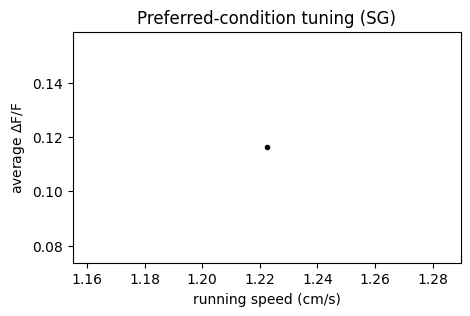

In [7]:
# Use preferred-condition trials only
st_sg_pref = SpeedTuning(td_sg, mode=mode, trial_mask=pref_trial_mask)
st_sg_pref.run()

print(f"rho shape: {st_sg_pref.rho.shape}")
print(f"significant_mask sum: {st_sg_pref.significant_mask.sum()}")
st_sg_pref.plot_tuning_curve(semcolor='blue')
plt.title('Preferred-condition tuning (SG)')
plt.show()

## Test 6: Combined neuron_mask + trial_mask

In [8]:
# Use half-mask neurons + preferred-condition trials
st_combined = SpeedTuning(td_sg, mode=mode, neuron_mask=half_mask, trial_mask=pref_trial_mask)
st_combined.run()

print(f"mean_all_responses shape: {st_combined.mean_all_responses.shape}")
print(f"Expected: ({half_mask.sum()}, {st_combined.n_bins})")
print(f"significant_mask sum: {st_combined.significant_mask.sum()}")

mean_all_responses shape: (23, 20)
Expected: (23, 20)
significant_mask sum: 23


## Test 7: plot_monotonicity_grid with modulated_mask

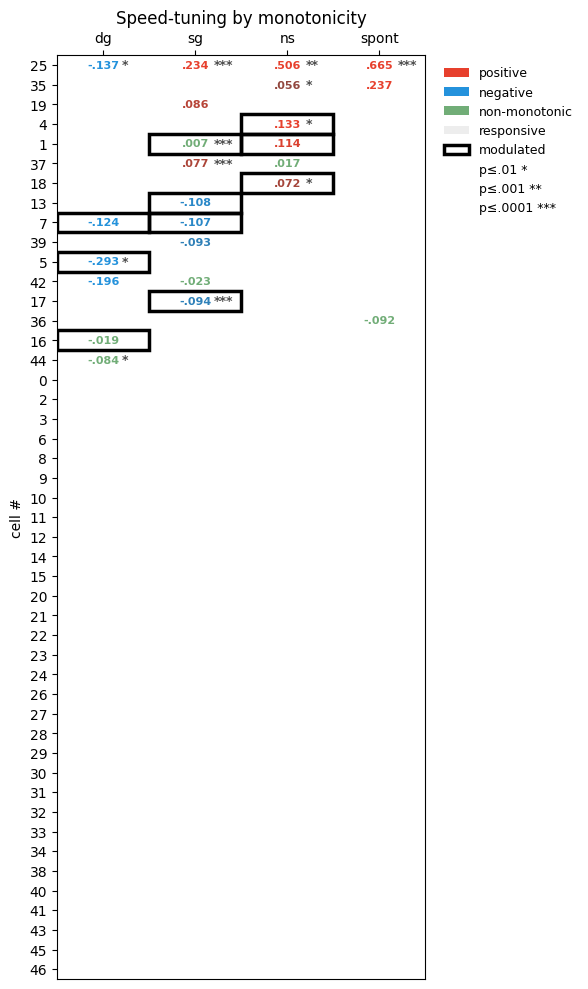

In [9]:
# Run SpeedTuning for all stimuli (without masks, for baseline comparison)
tunings = {label: SpeedTuning(trial_data_dict[stim], mode=mode) for (label, stim) in zip(SHORT_STIM, STIMULI)}
for stim in SHORT_STIM:
    tunings[stim].run()

# Construct a toy modulated_mask for illustration
toy_modulated = {}
for stim_label, stim_name in zip(SHORT_STIM, STIMULI):
    if stim_name != 'spontaneous':
        # Mark ~half of significant neurons as modulated
        sig = tunings[stim_label].significant_mask
        mod = np.zeros(N_CELLS, dtype=bool)
        sig_idx = np.where(sig)[0]
        if len(sig_idx) > 0:
            n_mod = max(1, len(sig_idx) // 2)
            mod[sig_idx[:n_mod]] = True
        toy_modulated[stim_label] = mod
    else:
        toy_modulated[stim_label] = np.zeros(N_CELLS, dtype=bool)

fig = plot_monotonicity_grid(tunings, modulated_mask=toy_modulated)
plt.show()

## Test 8: plot_modulated_tuned_grid

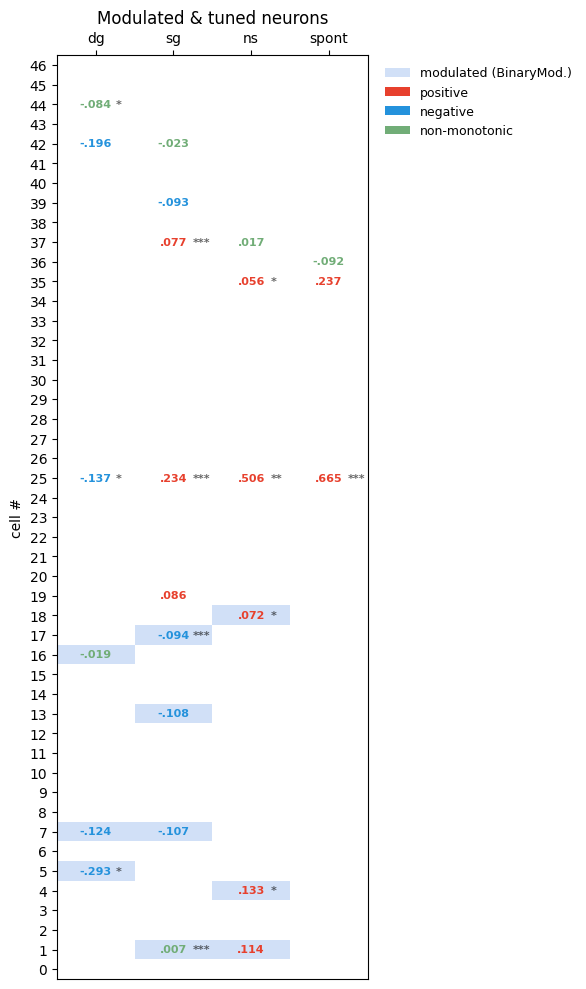

In [10]:
fig = plot_modulated_tuned_grid(tunings, modulated_mask=toy_modulated)
plt.show()

## Test 9: MI annotation in plot_tuning_by_monotonicity

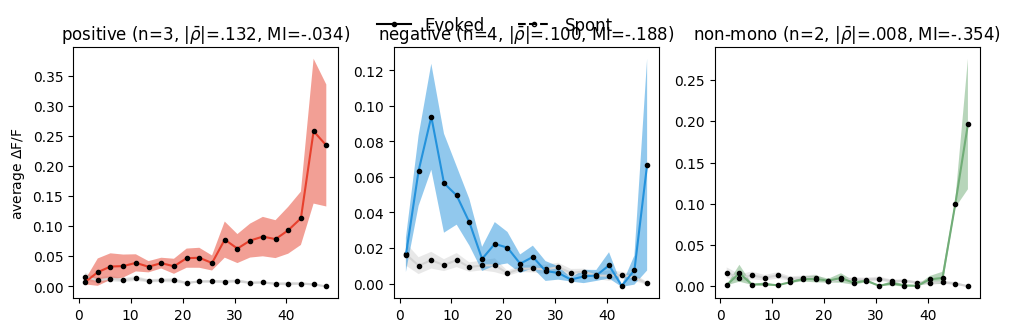

In [11]:
# Use toy MI values
toy_mi = np.random.default_rng(123).uniform(-0.5, 0.5, N_CELLS)
tunings['sg'].plot_tuning_by_monotonicity(mi=toy_mi)
plt.show()